In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
file_path='..\..\..\Farm\DATA\d.csv'
df = pd.read_csv(file_path, parse_dates=['timestamp'])

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\dipes\AppData\Local\Temp\ipykernel_31308\1968067123.py:1: SyntaxWarning: invalid escape sequence '\.'
  file_path='..\..\..\Farm\DATA\d.csv'


In [18]:
df.head()
df.describe()

,timestamp,raw_weight_kg
count,5000,5000.000000
mean,2025-08-17 12:56:35,1.490723
min,2025-08-17 06:00:00,-0.150976
25%,2025-08-17 09:28:17.500000,0.065906
50%,2025-08-17 12:56:35,1.447337
75%,2025-08-17 16:24:52.500000,2.292677
max,2025-08-17 19:53:10,4.956841
std,NaN,1.189107


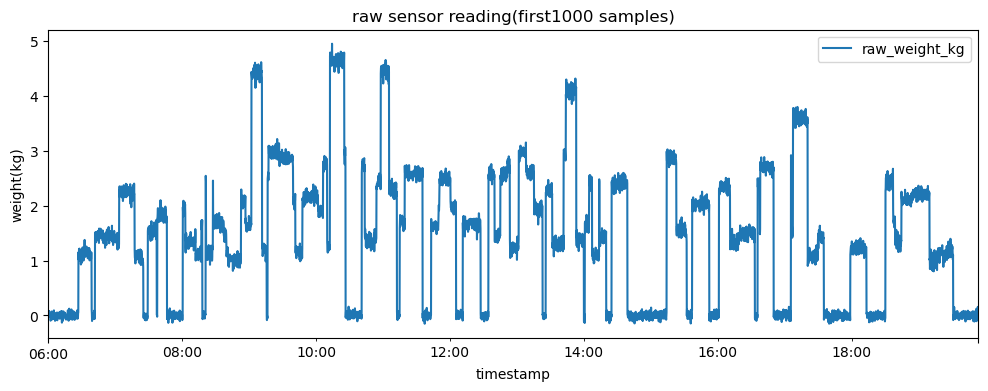

In [19]:
df.plot(x='timestamp', y='raw_weight_kg', figsize=(12,4))
plt.ylabel('weight(kg)')
plt.title('raw sensor reading(first1000 samples)')
plt.show()


In [20]:
import numpy as np


In [21]:
occupied = df["raw_weight_kg"] > 0.93 # Boolean mask
df["occupied"] = occupied.astype(int)

# Find transitions
df["shift"] = df["occupied"].diff().fillna(0)

event_starts = df.index[df["shift"] == 1].tolist()
event_ends   = df.index[df["shift"] == -1].tolist()

#Handle case where plate occupied at the end
if len(event_ends) < len(event_starts):
    event_ends.append(df.index[-1])

events = list(zip(event_starts, event_ends))
print("Detected events:", len(events))


Detected events: 45


In [22]:
print(events)

[(163, 176), (177, 234), (252, 499), (501, 511), (536, 584), (587, 639), (724, 829), (847, 870), (871, 968), (969, 972), (973, 993), (994, 998), (999, 1000), (1001, 1007), (1008, 1016), (1017, 1019), (1020, 1022), (1024, 1031), (1032, 1175), (1180, 1599), (1686, 1875), (1890, 2013), (2059, 2193), (2229, 2325), (2367, 2658), (2675, 2880), (2885, 3000), (3029, 3114), (3325, 3433), (3462, 3554), (3606, 3799), (3814, 3900), (3993, 4083), (4084, 4124), (4125, 4170), (4312, 4399), (4501, 4740), (4741, 4749), (4750, 4754), (4755, 4760), (4761, 4767), (4768, 4769), (4770, 4778), (4779, 4812), (4813, 4865)]


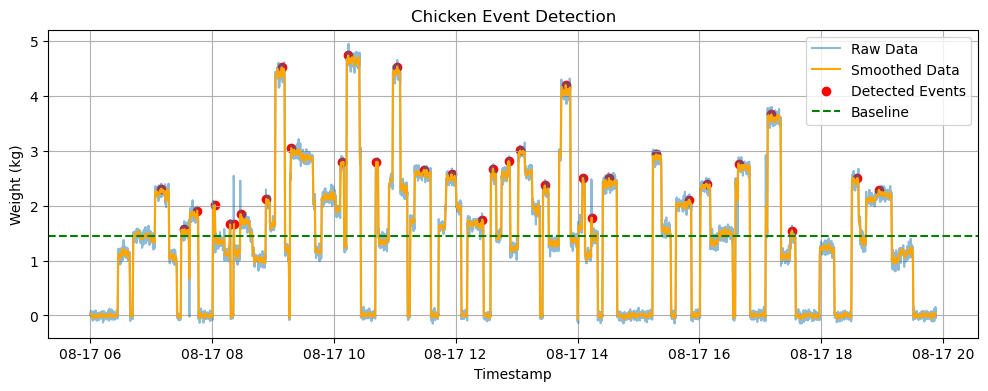

Detected 33 potential chicken events


In [23]:
from scipy.signal import find_peaks
# Smooth the data to reduce noise (moving average)
window_size = 5  # Adjust based on your data frequency
df['smoothed_weight'] = df['raw_weight_kg'].rolling(window=window_size, center=True).mean()

# Calculate baseline (median works well for this type of data)
baseline = df['raw_weight_kg'].median()

# Detect peaks - these are our chicken events
peaks, properties = find_peaks(
    df['smoothed_weight'],
    height=baseline,  # Threshold above baseline (adjust based on your data)
    distance=1,         # Minimum samples between peaks (adjust based on chicken behavior)
    prominence=0.5       # How much the peak stands out (adjust based on your data)
)

# Plot the results
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['raw_weight_kg'], label='Raw Data', alpha=0.5)
plt.plot(df['timestamp'], df['smoothed_weight'], label='Smoothed Data', color='orange')
plt.scatter(df['timestamp'].iloc[peaks], df['smoothed_weight'].iloc[peaks], 
            color='red', label='Detected Events')
plt.axhline(y=baseline, color='green', linestyle='--', label='Baseline')
plt.xlabel('Timestamp')
plt.ylabel('Weight (kg)')
plt.title('Chicken Event Detection')
plt.legend()
plt.grid(True)
plt.show()

print(f"Detected {len(peaks)} potential chicken events")

            timestamp  max_weight  duration  area_under_curve  rise_time  \
0 2025-08-17 07:10:00    2.401411       2.0         15.655706        0.8   
1 2025-08-17 07:32:40    1.719268       2.0          1.105007        0.9   
2 2025-08-17 07:45:10    1.985666       2.0          4.342413        0.9   
3 2025-08-17 08:02:20    2.092091       2.0          6.118316        0.3   
4 2025-08-17 08:17:40    1.739639       2.0        -11.030016        1.2   

   baseline  
0  1.447337  
1  1.447337  
2  1.447337  
3  1.447337  
4  1.447337  


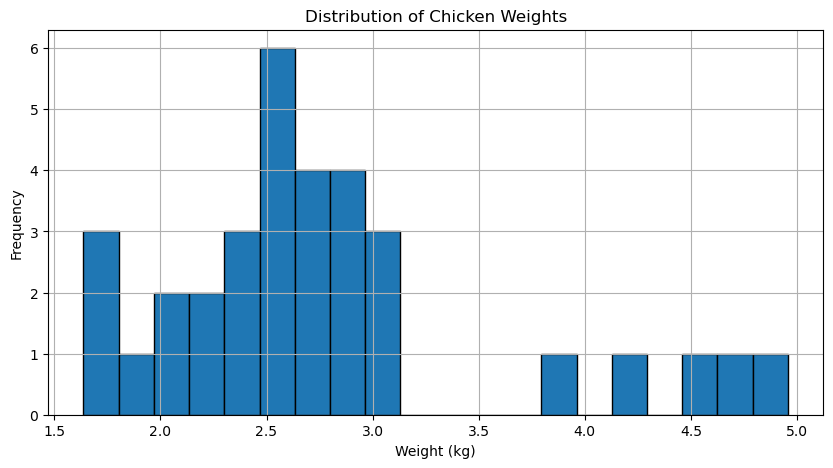

In [24]:
# Extract features from each detected event
event_features = []
for peak in peaks:
    event_start = max(0, peak - 10)  # Look 10 samples before peak
    event_end = min(len(df), peak + 10)  # Look 10 samples after peak
    
    event_data = df.iloc[event_start:event_end]
    
    features = {
        'timestamp': df['timestamp'].iloc[peak],
        'max_weight': event_data['raw_weight_kg'].max(),
        'duration': len(event_data) / 10,  # Assuming 10Hz sampling rate
        'area_under_curve': np.trapz(event_data['raw_weight_kg'] - baseline),
        'rise_time': np.argmax(event_data['raw_weight_kg']) / 10,  # Time to peak
        'baseline': baseline
    }
    event_features.append(features)

# Create a DataFrame of events
events_df = pd.DataFrame(event_features)
print(events_df.head())

# Plot histogram of event weights
plt.figure(figsize=(10, 5))
plt.hist(events_df['max_weight'], bins=20, edgecolor='black')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.title('Distribution of Chicken Weights')
plt.grid(True)
plt.show()

c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Optimal number of clusters: 2


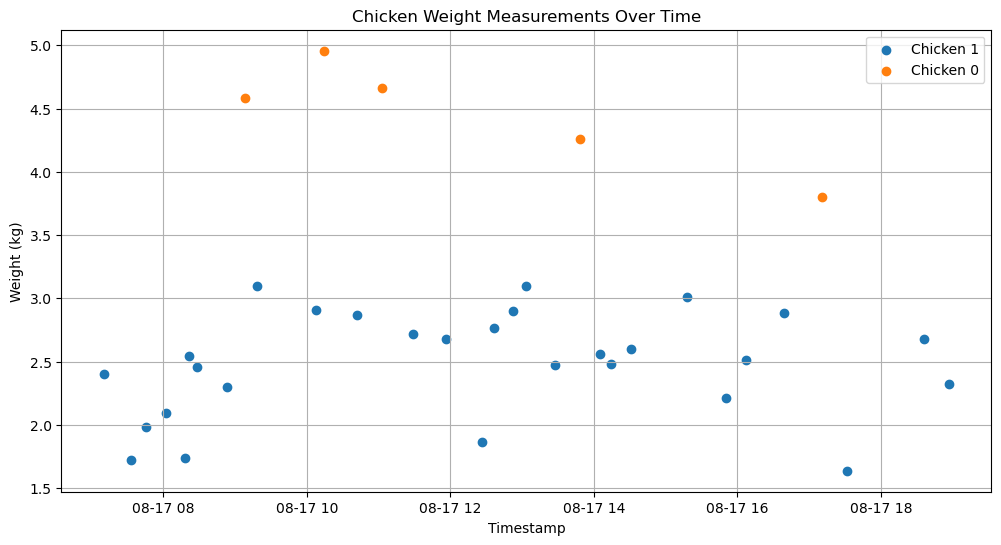

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster the weights to estimate number of chickens
weights = events_df[['max_weight']].values

# Determine optimal number of clusters using silhouette score
range_n_clusters = range(2, 6)
best_score = -1
best_n = 2

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(weights)
    silhouette_avg = silhouette_score(weights, cluster_labels)
    
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_n = n_clusters

print(f"Optimal number of clusters: {best_n}")

# Fit with optimal clusters
kmeans = KMeans(n_clusters=best_n, random_state=42)
events_df['chicken_id'] = kmeans.fit_predict(weights)

# Plot clustered weights over time
plt.figure(figsize=(12, 6))
for chicken_id in events_df['chicken_id'].unique():
    chicken_data = events_df[events_df['chicken_id'] == chicken_id]
    plt.scatter(chicken_data['timestamp'], chicken_data['max_weight'], 
                label=f'Chicken {chicken_id}')

plt.xlabel('Timestamp')
plt.ylabel('Weight (kg)')
plt.title('Chicken Weight Measurements Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print(weights)
print(weights.shape)

[[2.40141103]
 [1.71926822]
 [1.98566635]
 [2.09209073]
 [1.73963918]
 [2.54677058]
 [2.45924032]
 [2.29820345]
 [4.58056192]
 [3.09427719]
 [2.90966883]
 [4.95684105]
 [2.86928532]
 [4.66025769]
 [2.72068271]
 [2.68047166]
 [1.86447691]
 [2.76168545]
 [2.90187313]
 [3.09689429]
 [2.47224995]
 [4.2574298 ]
 [2.55590112]
 [2.48382913]
 [2.59956521]
 [3.01351775]
 [2.2107476 ]
 [2.51041842]
 [2.88373956]
 [3.80417624]
 [1.63680588]
 [2.67602652]
 [2.32180826]]
(33, 1)


In [27]:
silhouette_avg = np.mean(weights, axis=0)
print(f"Average weight: {silhouette_avg[0]:.3f} kg")

Average weight: 2.781 kg


In [60]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score, silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# USER SETTINGS
# =========================
INPUT_CSV = os.path.normpath(os.path.join("..", "..", "..", "Farm", "DATA", "reference_dataset.csv"))
TIMESTAMP_COL = "timestamp"                 # set None if not present
SENSOR_COL = "raw_weight_kg"                # your measured sensor column
REFERENCE_COL = "raw_weight_kg_ref"         # dummy / actual reference column
OUTPUT_DIR = os.path.normpath(os.path.join("..", "..", "..", "Farm", "DATA","analysis_outputs"))


os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(INPUT_CSV)

if TIMESTAMP_COL in df.columns:
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
    df = df.sort_values(TIMESTAMP_COL)

required_cols = [SENSOR_COL, REFERENCE_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

analysis_df = df[[c for c in [TIMESTAMP_COL, SENSOR_COL, REFERENCE_COL] if c in df.columns]].copy()

# =========================
# BASIC CLEANING
# =========================
analysis_df[SENSOR_COL] = pd.to_numeric(analysis_df[SENSOR_COL], errors="coerce")
analysis_df[REFERENCE_COL] = pd.to_numeric(analysis_df[REFERENCE_COL], errors="coerce")

# Remove rows where both are missing
analysis_df = analysis_df.dropna(subset=[SENSOR_COL, REFERENCE_COL], how="any").reset_index(drop=True)

# Optional: remove impossible values if needed
# Example for weight:
# analysis_df = analysis_df[(analysis_df[SENSOR_COL] >= 0) & (analysis_df[REFERENCE_COL] >= 0)]

# =========================
# OUTLIER HANDLING (IQR)
# =========================
def iqr_filter(df_in, cols):
    mask = pd.Series(True, index=df_in.index)
    for col in cols:
        q1 = df_in[col].quantile(0.25)
        q3 = df_in[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask &= df_in[col].between(lower, upper)
    return df_in[mask].copy()

clean_df = iqr_filter(analysis_df, [SENSOR_COL, REFERENCE_COL]).reset_index(drop=True)

# Save cleaned data
clean_df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_data.csv"), index=False)

# =========================
# DESCRIPTIVE STATISTICS
# =========================
desc = pd.DataFrame({
    "metric": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    SENSOR_COL: [
        clean_df[SENSOR_COL].count(),
        clean_df[SENSOR_COL].mean(),
        clean_df[SENSOR_COL].std(),
        clean_df[SENSOR_COL].min(),
        clean_df[SENSOR_COL].quantile(0.25),
        clean_df[SENSOR_COL].median(),
        clean_df[SENSOR_COL].quantile(0.75),
        clean_df[SENSOR_COL].max(),
    ],
    REFERENCE_COL: [
        clean_df[REFERENCE_COL].count(),
        clean_df[REFERENCE_COL].mean(),
        clean_df[REFERENCE_COL].std(),
        clean_df[REFERENCE_COL].min(),
        clean_df[REFERENCE_COL].quantile(0.25),
        clean_df[REFERENCE_COL].median(),
        clean_df[REFERENCE_COL].quantile(0.75),
        clean_df[REFERENCE_COL].max(),
    ]
})
desc.to_csv(os.path.join(OUTPUT_DIR, "descriptive_statistics.csv"), index=False)

# =========================
# ERROR METRICS
# =========================
y_true = clean_df[REFERENCE_COL].values
y_pred = clean_df[SENSOR_COL].values

errors = y_pred - y_true
abs_errors = np.abs(errors)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mse = mean_squared_error(y_true, y_pred)
bias = np.mean(errors)
std_error = np.std(errors, ddof=1)
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
median_ae = np.median(abs_errors)

error_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MSE", "Bias", "Std_Error", "Median_AE", "MAPE_percent"],
    "value": [mae, rmse, mse, bias, std_error, median_ae, mape]
})
error_metrics.to_csv(os.path.join(OUTPUT_DIR, "error_metrics.csv"), index=False)

# =========================
# CORRELATION ANALYSIS
# =========================
pearson_r, pearson_p = stats.pearsonr(y_pred, y_true)
spearman_rho, spearman_p = stats.spearmanr(y_pred, y_true)

correlation_results = pd.DataFrame({
    "test": ["Pearson", "Spearman"],
    "coefficient": [pearson_r, spearman_rho],
    "p_value": [pearson_p, spearman_p]
})
correlation_results.to_csv(os.path.join(OUTPUT_DIR, "correlation_results.csv"), index=False)

# =========================
# REGRESSION ANALYSIS
# =========================
slope, intercept, r_value, p_value_reg, std_err_reg = stats.linregress(y_true, y_pred)
regression_df = pd.DataFrame({
    "metric": ["slope", "intercept", "r_value", "r_squared", "p_value", "std_err"],
    "value": [slope, intercept, r_value, r_value**2, p_value_reg, std_err_reg]
})
regression_df.to_csv(os.path.join(OUTPUT_DIR, "regression_results.csv"), index=False)

# =========================
# BLAND-ALTMAN ANALYSIS
# =========================
mean_pair = (y_pred + y_true) / 2
diff_pair = y_pred - y_true

ba_bias = np.mean(diff_pair)
ba_sd = np.std(diff_pair, ddof=1)
loa_upper = ba_bias + 1.96 * ba_sd
loa_lower = ba_bias - 1.96 * ba_sd
outside_loa = np.mean((diff_pair > loa_upper) | (diff_pair < loa_lower)) * 100

# proportional bias: regress difference against mean
pb_slope, pb_intercept, pb_r, pb_p, pb_stderr = stats.linregress(mean_pair, diff_pair)

bland_altman_results = pd.DataFrame({
    "metric": [
        "bias",
        "sd_of_difference",
        "upper_limit_of_agreement",
        "lower_limit_of_agreement",
        "percent_outside_loa",
        "proportional_bias_slope",
        "proportional_bias_p_value"
    ],
    "value": [
        ba_bias,
        ba_sd,
        loa_upper,
        loa_lower,
        outside_loa,
        pb_slope,
        pb_p
    ]
})
bland_altman_results.to_csv(os.path.join(OUTPUT_DIR, "bland_altman_results.csv"), index=False)

# =========================
# PAIRED STATISTICAL TESTS
# =========================
# normality of differences
shapiro_stat, shapiro_p = stats.shapiro(diff_pair[:5000] if len(diff_pair) > 5000 else diff_pair)

if shapiro_p > 0.05:
    paired_stat, paired_p = stats.ttest_rel(y_pred, y_true)
    paired_test_name = "Paired t-test"
else:
    paired_stat, paired_p = stats.wilcoxon(y_pred, y_true)
    paired_test_name = "Wilcoxon signed-rank"

paired_test_results = pd.DataFrame({
    "metric": ["Shapiro_W", "Shapiro_p", "Test_Statistic", "Test_p_value"],
    "value": [shapiro_stat, shapiro_p, paired_stat, paired_p]
})
paired_test_results["test_name"] = ["Normality", "Normality", paired_test_name, paired_test_name]
paired_test_results.to_csv(os.path.join(OUTPUT_DIR, "paired_test_results.csv"), index=False)

# =========================
# ICC(2,1) APPROXIMATION
# Two-way random effects absolute agreement
# =========================
def icc2_1(data):
    """
    data shape: n_targets x k_raters
    """
    data = np.asarray(data, dtype=float)
    n, k = data.shape

    mean_target = np.mean(data, axis=1, keepdims=True)
    mean_rater = np.mean(data, axis=0, keepdims=True)
    grand_mean = np.mean(data)

    ss_total = np.sum((data - grand_mean) ** 2)
    ss_targets = k * np.sum((mean_target - grand_mean) ** 2)
    ss_raters = n * np.sum((mean_rater - grand_mean) ** 2)
    ss_error = ss_total - ss_targets - ss_raters

    df_targets = n - 1
    df_raters = k - 1
    df_error = (n - 1) * (k - 1)

    ms_targets = ss_targets / df_targets
    ms_raters = ss_raters / df_raters if df_raters != 0 else 0
    ms_error = ss_error / df_error if df_error != 0 else 0

    icc = (ms_targets - ms_error) / (
        ms_targets + (k - 1) * ms_error + (k * (ms_raters - ms_error) / n)
    )
    return icc

icc_value = icc2_1(clean_df[[SENSOR_COL, REFERENCE_COL]].values)
icc_df = pd.DataFrame({"metric": ["ICC_2_1"], "value": [icc_value]})
icc_df.to_csv(os.path.join(OUTPUT_DIR, "icc_results.csv"), index=False)

# =========================
# CLUSTERING VALIDATION
# =========================
# Build features from both sensor and reference
cluster_df = clean_df[[SENSOR_COL, REFERENCE_COL]].copy()

# Impute if needed
imputer = SimpleImputer(strategy="median")
cluster_imputed = imputer.fit_transform(cluster_df)

# Scale
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_imputed)

# Test k = 2 to 5
cluster_rows = []
best_k = None
best_sil = -np.inf

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)

    sil = silhouette_score(cluster_scaled, labels)
    dbi = davies_bouldin_score(cluster_scaled, labels)

    cluster_rows.append({
        "k": k,
        "silhouette_score": sil,
        "davies_bouldin_index": dbi
    })

    if sil > best_sil:
        best_sil = sil
        best_k = k

cluster_validation_df = pd.DataFrame(cluster_rows)
cluster_validation_df.to_csv(os.path.join(OUTPUT_DIR, "clustering_validation.csv"), index=False)

# Final clustering with best k
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = best_kmeans.fit_predict(cluster_scaled)
clean_df["cluster_label"] = final_labels
clean_df.to_csv(os.path.join(OUTPUT_DIR, "data_with_clusters.csv"), index=False)

# =========================
# TIME-SERIES / STABILITY ANALYSIS
# =========================
if TIMESTAMP_COL in clean_df.columns:
    temp = clean_df[[TIMESTAMP_COL, SENSOR_COL, REFERENCE_COL]].dropna().copy()
    temp["error"] = temp[SENSOR_COL] - temp[REFERENCE_COL]
    temp["abs_error"] = temp["error"].abs()

    # rolling stats
    window = min(30, max(5, len(temp) // 20))
    temp["sensor_rolling_mean"] = temp[SENSOR_COL].rolling(window=window, min_periods=1).mean()
    temp["ref_rolling_mean"] = temp[REFERENCE_COL].rolling(window=window, min_periods=1).mean()
    temp["error_rolling_mean"] = temp["error"].rolling(window=window, min_periods=1).mean()
    temp["error_rolling_std"] = temp["error"].rolling(window=window, min_periods=1).std()

    temp.to_csv(os.path.join(OUTPUT_DIR, "time_series_stability.csv"), index=False)

# =========================
# SUMMARY TABLE
# =========================
summary_table = pd.DataFrame({
    "Metric": [
        "Sample Size",
        "Pearson r",
        "Spearman rho",
        "MAE",
        "RMSE",
        "Bias",
        "MAPE (%)",
        "Regression Slope",
        "Regression Intercept",
        "R^2",
        "Bland-Altman Bias",
        "Upper LoA",
        "Lower LoA",
        "% Outside LoA",
        "ICC(2,1)",
        "Best Cluster k",
        "Best Silhouette Score"
    ],
    "Value": [
        len(clean_df),
        pearson_r,
        spearman_rho,
        mae,
        rmse,
        bias,
        mape,
        slope,
        intercept,
        r_value**2,
        ba_bias,
        loa_upper,
        loa_lower,
        outside_loa,
        icc_value,
        best_k,
        best_sil
    ]
})
summary_table.to_csv(os.path.join(OUTPUT_DIR, "summary_results.csv"), index=False)

print("Analysis complete.")
print(f"Outputs saved to: {OUTPUT_DIR}")
print(summary_table)

Analysis complete.
Outputs saved to: ..\..\..\Farm\DATA\analysis_outputs
                   Metric        Value
0             Sample Size  5000.000000
1               Pearson r     0.998765
2            Spearman rho     0.998245
3                     MAE     0.047239
4                    RMSE     0.059241
5                    Bias    -0.000333
6                MAPE (%)    16.837403
7        Regression Slope     0.996340
8    Regression Intercept     0.005124
9                     R^2     0.997531
10      Bland-Altman Bias    -0.000333
11              Upper LoA     0.115789
12              Lower LoA    -0.116455
13          % Outside LoA     5.140000
14               ICC(2,1)     0.998762
15         Best Cluster k     4.000000
16  Best Silhouette Score     0.734862


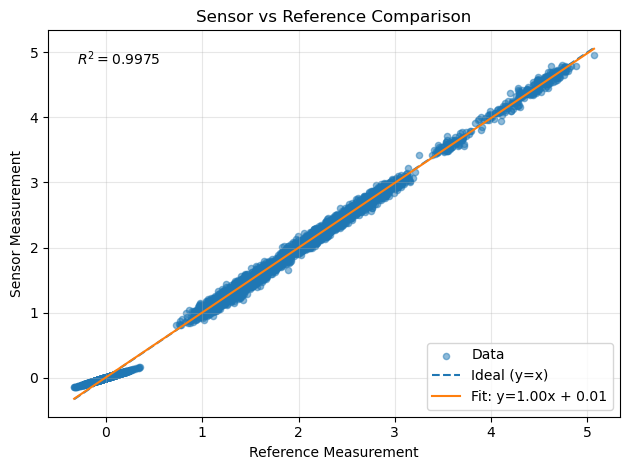

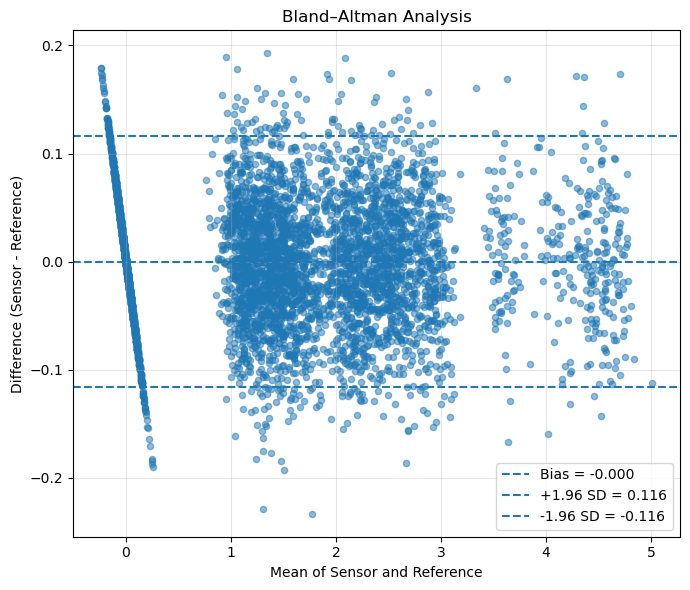

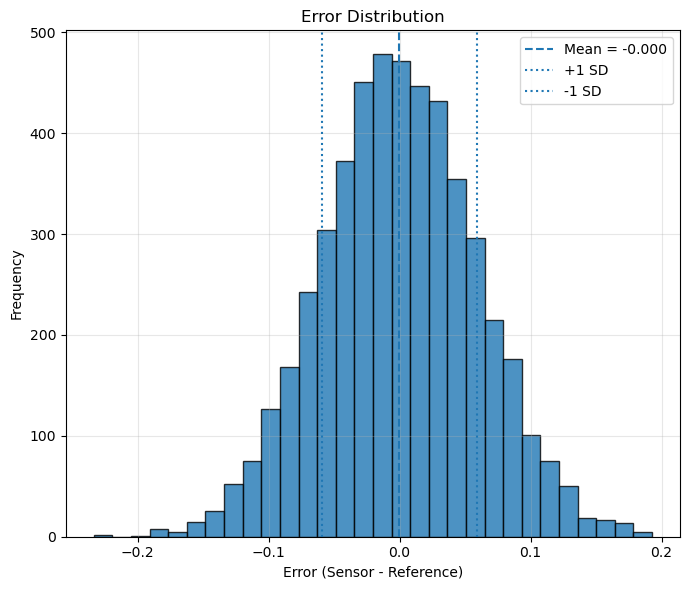

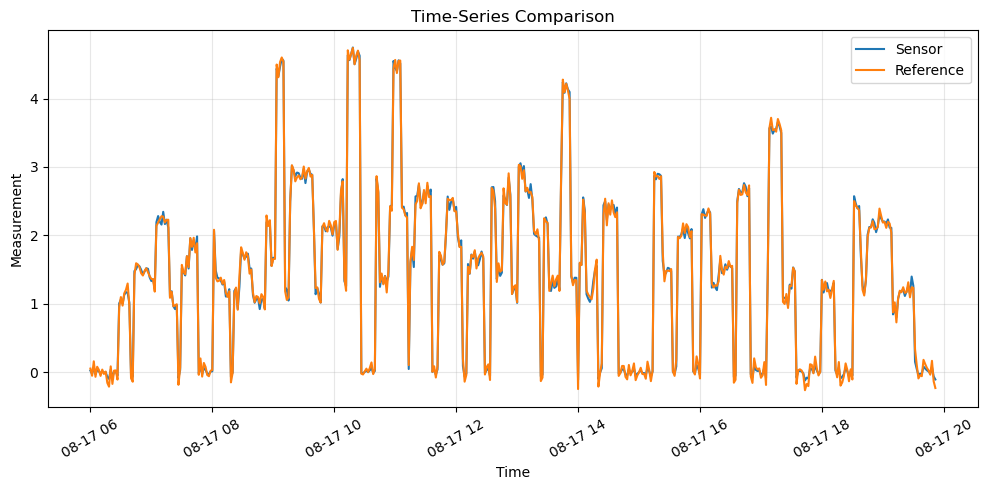

In [58]:
# Optional plotting toggle

GENERATE_PLOTS = False

if GENERATE_PLOTS:
    plt.figure(figsize=(7, 6))

plt.scatter(clean_df[REFERENCE_COL], clean_df[SENSOR_COL],
            alpha=0.5, s=20, label="Data")

# Identity line
x = np.linspace(clean_df[REFERENCE_COL].min(),
                clean_df[REFERENCE_COL].max(), 100)
plt.plot(x, x, linestyle="--", label="Ideal (y=x)")

# Regression line
y_fit = slope * x + intercept
plt.plot(x, y_fit, label=f"Fit: y={slope:.2f}x + {intercept:.2f}")

plt.xlabel("Reference Measurement")
plt.ylabel("Sensor Measurement")
plt.title("Sensor vs Reference Comparison")

# Add R² annotation
plt.text(0.05, 0.95,
         f"$R^2 = {r_value**2:.4f}$",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save scatter + regression plot
plt.figure(figsize=(7, 6))

plt.scatter(mean_pair, diff_pair, alpha=0.5, s=20)

plt.axhline(ba_bias, linestyle="--", label=f"Bias = {ba_bias:.3f}")
plt.axhline(loa_upper, linestyle="--", label=f"+1.96 SD = {loa_upper:.3f}")
plt.axhline(loa_lower, linestyle="--", label=f"-1.96 SD = {loa_lower:.3f}")

plt.xlabel("Mean of Sensor and Reference")
plt.ylabel("Difference (Sensor - Reference)")
plt.title("Bland–Altman Analysis")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Error histogram
plt.figure(figsize=(7, 6))

plt.hist(diff_pair, bins=30, alpha=0.8, edgecolor='black')

plt.axvline(ba_bias, linestyle="--", label=f"Mean = {ba_bias:.3f}")
plt.axvline(ba_bias + ba_sd, linestyle=":", label="+1 SD")
plt.axvline(ba_bias - ba_sd, linestyle=":", label="-1 SD")

plt.xlabel("Error (Sensor - Reference)")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


# 4. Time series overlay
plt.figure(figsize=(10, 5))

# downsample for clarity
sampled = clean_df.iloc[::10]

plt.plot(sampled[TIMESTAMP_COL], sampled[SENSOR_COL], label="Sensor")
plt.plot(sampled[TIMESTAMP_COL], sampled[REFERENCE_COL], label="Reference")

plt.xlabel("Time")
plt.ylabel("Measurement")
plt.title("Time-Series Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()



In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# =========================
# SETTINGS
# =========================
INPUT_FILE = "../../DATA/environment_dataset.csv"
OUTPUT_DIR = "../../DATA/analysis_outputs/publication_sensors_output"
#os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sensors
sensor_pairs = [
    ("temperature", "temperature_ref"),
    ("humidity", "humidity_ref"),
    ("co2", "co2_ref"),
    ("ammonia", "ammonia_ref")
]

df = pd.read_csv(INPUT_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# =========================
# GLOBAL STYLE (journal-like)
# =========================
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10
})

summary_results = []

# =========================
# LOOP THROUGH ALL SENSORS
# =========================
for sensor, ref in sensor_pairs:

    clean_df = df[[sensor, ref, "timestamp"]].dropna().copy()

    y_pred = clean_df[sensor].values
    y_true = clean_df[ref].values

    # =========================
    # ERROR METRICS
    # =========================
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)

    # =========================
    # CORRELATION
    # =========================
    r, _ = stats.pearsonr(y_pred, y_true)

    # =========================
    # REGRESSION
    # =========================
    slope, intercept, r_val, _, _ = stats.linregress(y_true, y_pred)

    # =========================
    # BLAND-ALTMAN
    # =========================
    mean_pair = (y_pred + y_true) / 2
    diff = y_pred - y_true

    ba_bias = np.mean(diff)
    ba_sd = np.std(diff)
    loa_upper = ba_bias + 1.96 * ba_sd
    loa_lower = ba_bias - 1.96 * ba_sd

    # =========================
    # SAVE METRICS
    # =========================
    summary_results.append({
        "sensor": sensor,
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "Pearson_r": r,
        "R2": r_val**2,
        "BA_bias": ba_bias,
        "Upper_LoA": loa_upper,
        "Lower_LoA": loa_lower
    })

    # =========================
    # PLOTS
    # =========================

    # 📈 SCATTER
    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(y_true, y_pred, s=18, alpha=0.6)

    x = np.linspace(min(y_true), max(y_true), 100)
    plt.plot(x, x, '--', label="Ideal")
    plt.plot(x, slope*x + intercept, label="Fit")

    plt.xlabel("Reference")
    plt.ylabel("Sensor")
    plt.title(f"{sensor.capitalize()} vs Reference")

    plt.text(0.05, 0.95, f"$R^2={r_val**2:.3f}$",
             transform=plt.gca().transAxes)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{sensor}_scatter.png", dpi=300)
    plt.close()

    # 📉 BLAND-ALTMAN
    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(mean_pair, diff, s=18, alpha=0.6)

    plt.axhline(ba_bias, linestyle="--", label="Bias")
    plt.axhline(loa_upper, linestyle="--", label="+1.96SD")
    plt.axhline(loa_lower, linestyle="--", label="-1.96SD")

    plt.xlabel("Mean")
    plt.ylabel("Difference")
    plt.title(f"Bland-Altman: {sensor}")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{sensor}_bland_altman.png", dpi=300)
    plt.close()

    # 📊 ERROR HISTOGRAM
    plt.figure(figsize=(6.5, 5.5))
    plt.hist(diff, bins=30, edgecolor='black')

    plt.axvline(ba_bias, linestyle="--")

    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.title(f"Error Distribution: {sensor}")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{sensor}_error.png", dpi=300)
    plt.close()

# =========================
# SAVE SUMMARY TABLE
# =========================
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv(f"{OUTPUT_DIR}/summary_results.csv", index=False)

print("All publication plots and tables generated.")

All publication plots and tables generated.


In [74]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# SETTINGS
# =========================
INPUT_FILE = "../../DATA/environment_dataset.csv"   # change if needed
OUTPUT_DIR = "../../DATA/analysis_outputs/publication_sensors_output/latex_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Candidate sensor-reference pairs
candidate_pairs = [
    ("temperature", "temperature_ref", "Temperature"),
    ("humidity", "humidity_ref", "Humidity"),
    ("co2", "co2_ref", "CO$_2$"),
    ("ammonia", "ammonia_ref", "Ammonia"),
    ("weight", "weight_ref", "Weight"),
    ("raw_weight_kg", "raw_weight_kg_ref", "Weight"),
]

# =========================
# LOAD
# =========================
df = pd.read_csv(INPUT_FILE)

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Keep only available pairs
sensor_pairs = []
seen_labels = set()
for sensor, ref, label in candidate_pairs:
    if sensor in df.columns and ref in df.columns:
        # avoid duplicate weight entry if both naming styles exist
        if label not in seen_labels:
            sensor_pairs.append((sensor, ref, label))
            seen_labels.add(label)

if not sensor_pairs:
    raise ValueError("No valid sensor/reference column pairs found in the CSV.")

# =========================
# HELPERS
# =========================
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def icc2_1(data):
    data = np.asarray(data, dtype=float)
    n, k = data.shape

    mean_target = np.mean(data, axis=1, keepdims=True)
    mean_rater = np.mean(data, axis=0, keepdims=True)
    grand_mean = np.mean(data)

    ss_total = np.sum((data - grand_mean) ** 2)
    ss_targets = k * np.sum((mean_target - grand_mean) ** 2)
    ss_raters = n * np.sum((mean_rater - grand_mean) ** 2)
    ss_error = ss_total - ss_targets - ss_raters

    df_targets = n - 1
    df_raters = k - 1
    df_error = (n - 1) * (k - 1)

    ms_targets = ss_targets / df_targets
    ms_raters = ss_raters / df_raters if df_raters != 0 else 0
    ms_error = ss_error / df_error if df_error != 0 else 0

    return (ms_targets - ms_error) / (
        ms_targets + (k - 1) * ms_error + (k * (ms_raters - ms_error) / n)
    )

def to_latex_table(df_table, caption, label, column_format=None):
    return df_table.to_latex(
        index=False,
        escape=False,
        caption=caption,
        label=label,
        column_format=column_format
    )

# =========================
# ANALYSIS
# =========================
desc_rows = []
performance_rows = []
agreement_rows = []

for sensor, ref, label in sensor_pairs:
    sub = df[[sensor, ref]].copy()
    sub[sensor] = pd.to_numeric(sub[sensor], errors="coerce")
    sub[ref] = pd.to_numeric(sub[ref], errors="coerce")
    sub = sub.dropna().reset_index(drop=True)

    if len(sub) < 3:
        continue

    y_pred = sub[sensor].values
    y_true = sub[ref].values

    # Descriptive
    desc_rows.append({
        "Variable": label,
        "n": len(sub),
        "Sensor Mean": np.mean(y_pred),
        "Sensor SD": np.std(y_pred, ddof=1),
        "Reference Mean": np.mean(y_true),
        "Reference SD": np.std(y_true, ddof=1),
        "Sensor Min": np.min(y_pred),
        "Sensor Max": np.max(y_pred),
        "Reference Min": np.min(y_true),
        "Reference Max": np.max(y_true),
    })

    # Performance
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    mape = safe_mape(y_true, y_pred)

    pearson_r, pearson_p = stats.pearsonr(y_pred, y_true)
    slope, intercept, r_val, reg_p, std_err = stats.linregress(y_true, y_pred)

    performance_rows.append({
        "Variable": label,
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "MAPE (\\%)": mape,
        "Pearson $r$": pearson_r,
        "$p$-value": pearson_p,
        "Slope": slope,
        "Intercept": intercept,
        "$R^2$": r_val**2,
    })

    # Agreement
    diff = y_pred - y_true
    mean_pair = (y_pred + y_true) / 2

    ba_bias = np.mean(diff)
    ba_sd = np.std(diff, ddof=1)
    loa_upper = ba_bias + 1.96 * ba_sd
    loa_lower = ba_bias - 1.96 * ba_sd
    pct_outside = np.mean((diff > loa_upper) | (diff < loa_lower)) * 100

    try:
        shapiro_stat, shapiro_p = stats.shapiro(diff[:5000] if len(diff) > 5000 else diff)
    except Exception:
        shapiro_stat, shapiro_p = np.nan, np.nan

    try:
        icc_val = icc2_1(sub[[sensor, ref]].values)
    except Exception:
        icc_val = np.nan

    agreement_rows.append({
        "Variable": label,
        "BA Bias": ba_bias,
        "BA SD": ba_sd,
        "Upper LoA": loa_upper,
        "Lower LoA": loa_lower,
        "Outside LoA (\\%)": pct_outside,
        "ICC(2,1)": icc_val,
        "Shapiro $p$": shapiro_p,
    })

# =========================
# DATAFRAMES
# =========================
desc_df = pd.DataFrame(desc_rows)
perf_df = pd.DataFrame(performance_rows)
agree_df = pd.DataFrame(agreement_rows)

# Round for publication
desc_df = desc_df.round(3)
perf_df = perf_df.round(4)
agree_df = agree_df.round(4)

# Save CSV too
desc_df.to_csv(os.path.join(OUTPUT_DIR, "descriptive_statistics.csv"), index=False)
perf_df.to_csv(os.path.join(OUTPUT_DIR, "performance_metrics.csv"), index=False)
agree_df.to_csv(os.path.join(OUTPUT_DIR, "agreement_metrics.csv"), index=False)

# =========================
# LATEX TABLES
# =========================
latex_desc = to_latex_table(
    desc_df,
    caption="Descriptive statistics for sensor and reference measurements across all monitored variables.",
    label="tab:descriptive_stats",
    column_format="lrrrrrrrrr"
)

latex_perf = to_latex_table(
    perf_df,
    caption="Performance metrics comparing sensor outputs against reference measurements.",
    label="tab:performance_metrics",
    column_format="lrrrrrrrrr"
)

latex_agree = to_latex_table(
    agree_df,
    caption="Agreement analysis based on Bland--Altman statistics and ICC for all monitored variables.",
    label="tab:agreement_metrics",
    column_format="lrrrrrrrr"
)

# Combined compact summary table
summary_df = perf_df[["Variable", "MAE", "RMSE", "Bias", "Pearson $r$", "$R^2$"]].merge(
    agree_df[["Variable", "BA Bias", "Upper LoA", "Lower LoA", "ICC(2,1)"]],
    on="Variable",
    how="inner"
).round(4)

latex_summary = to_latex_table(
    summary_df,
    caption="Compact summary of validation results across all variables.",
    label="tab:validation_summary",
    column_format="lrrrrrrrrr"
)

# Write individual tex files
with open(os.path.join(OUTPUT_DIR, "table_descriptive_stats.tex"), "w", encoding="utf-8") as f:
    f.write(latex_desc)

with open(os.path.join(OUTPUT_DIR, "table_performance_metrics.tex"), "w", encoding="utf-8") as f:
    f.write(latex_perf)

with open(os.path.join(OUTPUT_DIR, "table_agreement_metrics.tex"), "w", encoding="utf-8") as f:
    f.write(latex_agree)

with open(os.path.join(OUTPUT_DIR, "table_validation_summary.tex"), "w", encoding="utf-8") as f:
    f.write(latex_summary)

# Also write a single file containing all tables
all_tables = "\n\n".join([
    latex_desc,
    latex_perf,
    latex_agree,
    latex_summary
])

with open(os.path.join(OUTPUT_DIR, "all_tables.tex"), "w", encoding="utf-8") as f:
    f.write(all_tables)

print("LaTeX tables generated in:", OUTPUT_DIR)
print("Files:")
print("- table_descriptive_stats.tex")
print("- table_performance_metrics.tex")
print("- table_agreement_metrics.tex")
print("- table_validation_summary.tex")
print("- all_tables.tex")

LaTeX tables generated in: ../../DATA/analysis_outputs/publication_sensors_output/latex_outputs
Files:
- table_descriptive_stats.tex
- table_performance_metrics.tex
- table_agreement_metrics.tex
- table_validation_summary.tex
- all_tables.tex
